#### SPA6330: Artificial Intelligence and Machine Learning
#### MO: Dr Linda Cremonesi, today's notebook and slides in collaboration with Dr. Alexander Booth.

# Week 11: Neural Networks and Image Classification

**The goal of notebook is to study neural networks as a machine learning based tool to do image classification.**

<hr style="border:2px solid gray">

## Index: <a id='index'></a>
1. [MNIST Dataset](#dataset)
2. [Multilayer Perceptron](#mlp)

<hr style="border:2px solid gray">

## MNIST Dataset [^](#index) <a id='dataset'></a>
We will be using data from MNIST. Often called the "Hello World" dataset of machine learning, it is a set of 70000 instances. Each instance a hand written integer between 0 and 9, represented by a greyscale image with 28 x 28 pixels. This constitutes a 784 dimensional input feature space, where each feature is a number between 0 and 255 (8 bit greyscale).

For more information about the MNIST data set please see the website http://yann.lecun.com/exdb/mnist/.

Let's start with some of our usual imports, there are a few new ones since last week.

In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import pandas.plotting as pdp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics

# New imports for this week:
from sklearn.datasets import fetch_openml # Allows working with datasets available in sklearn, in our case MNIST.
from sklearn.neural_network import MLPClassifier

As before, the cell below changes the output options of some of the pandas printout statements, it will make the columms more readable.

In [10]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

The MNIST dataset is available through sklearn directly. The lines below grab the dataset and assign the dataset's features and targets to their own pandas dataframe / series.

In [12]:
raw_dataset_mnist = fetch_openml('mnist_784', parser='auto')
features = raw_dataset_mnist.data
targets = raw_dataset_mnist.target

Using pandas.DataFrame.head() / pandas.DataSeries.head(), check that the features and targets contain the type of information and you expect based on the  how the dataset was described at the top.

In [13]:
print(features.shape)
print(targets.shape)



(70000, 784)
(70000,)


In [8]:
# Note that targets is a pandas.DataSeries


<div style="background-color:#C2F5DD">

## Exercise 1
1. Size: How many instances in the dataset?
2. How balanced are the classes in the dataset? Show this visually, for example, through a 1D histogram.
4. What are the maximum and minimum values of pixel intensities across the dataset? Neural networks can be very sensistive to the scale of their input features, use sklearn.preprocessing.MinMaxScaler() so that pixel intensities lie on a scale from 0 to 1.
5. To allow training to converge in a reasonable time, take only the first 10000 instances of the whole dataset and split the resulting feature and target datasets into training (80% of the total), and testing (20% of the total) datasets using sklearn.model_selection.train_test_split() with the random state set to 2.
6. Plot the first 10 instances of the training set as 2D images. Do these instances look like their true class? 

In [14]:
#3 MAx and Min
print(f"OVerall Max: {np.max(features.values)}")
print(f"Overall Min: {np.min(features.values)}")


OVerall Max: 255
Overall Min: 0


In [10]:
#1 The Dataset contains 70000 intances

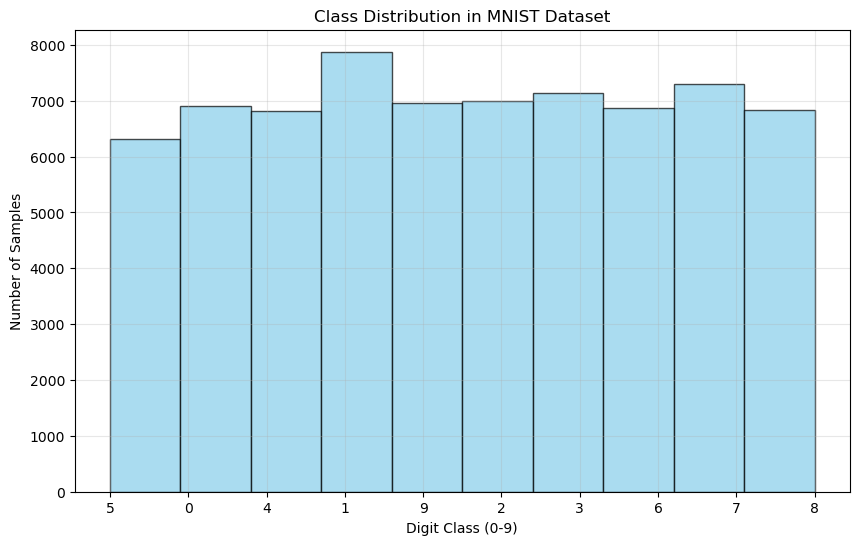

In [15]:
plt.figure(figsize=(10,6))
plt.hist(targets, bins= 10 , edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Digit Class (0-9)')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in MNIST Dataset')
plt.xticks(range(10))  # Show all digits 0-9 on x-axis
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
scaler = MinMaxScaler()
features_normalized = scaler.fit_transform(features)

In [17]:
#take only first 10000 instances
features_subset = features_normalized[:10000]
targets_subset = targets[:10000]

#split into 80% train and 20% test
X_train,X_Test,y_train, y_test = train_test_split(
    features_subset,
    targets_subset,
    test_size = 0.2,
    random_state = 2
)

KeyError: 3

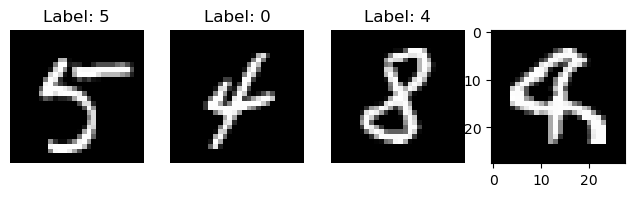

In [18]:
image_shape = (28,28)

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    image = X_train[i].reshape(image_shape)
    plt.imshow(image,cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


<hr style="border:2px solid gray">

## Multilayer Perceptron (MLP) [^](#index) <a id='mlp'></a>
In this section we'll start working with our first neural network, the Multilayer Perceptron Classifier (MLPClassifier) from scikit-learn. The cell below defines our model as one of these neural networks with the following arguments:
- `hidden_layer_sizes`: The number of nodes in each of the network's hidden layers. In the example given there are two hidden layers, each with 512 nodes.
- `max_iter`: The maximum number of training iterations or "epochs" that will run even if training has not "converged". During each epoch, all instances have been considered by the optimisation algorithm.
- `solver`: Defines the optimisation algorithm, we are using `adam`, a type of gradient decent.
- `tol`: Is the tolerance. If the loss does not change by more than `tol` for 10 consecutive epochs, the training stops.
- `random_state` is set so that results are reproducible and verbosity is set such that updates about the training are printed after each epoch.

This model from scikit-learn has the advantage that the sizes of the input and output layers are taken care of for you based on your training data!

In [20]:
model = MLPClassifier(hidden_layer_sizes=(512,512,), max_iter=100, solver="adam", tol=0.0001, random_state=1, verbose=True)

<div style="background-color:#C2F5DD">

## Exercise 2
1. How many nodes in the input layer of the MLP and why?
2. How many nodes in the output layer of the MLP and why?
3. Train the MLP we defined above on the scaled features using `fit` has we have in previous weeks. Comment on the value of the loss as training progresses.
4. What is the overall accuracy when evaluated on the test set? Produce the corresponding confusion matrix. Which two numbers are confused most often? Does this make sense?
6. Isolate the instances that the network got wrong and plot 49 of the examples. Add to each plot the true and predicted class (it can be as the x axis label). As a human would you have been able to get the answer correct?

In [21]:
X_train.shape


(8000, 784)

In [ ]:
#my input layer has 784 nodes because i am feeding a flattened 28x28 pixel image which is a vector of 784 numbers

In [22]:
len(np.unique(y_train))

10

In [ ]:
# my output layer is has 10 nodes because there are 10 uniques class labels in my y_train data

In [23]:
model.fit (X_train, y_train)   # the value of the loss keeps decreasing with each iteration

Iteration 1, loss = 0.65304716
Iteration 2, loss = 0.24595509
Iteration 3, loss = 0.15638387
Iteration 4, loss = 0.10503561
Iteration 5, loss = 0.07031605
Iteration 6, loss = 0.04947805
Iteration 7, loss = 0.03904355
Iteration 8, loss = 0.02316799
Iteration 9, loss = 0.01394209
Iteration 10, loss = 0.01027439
Iteration 11, loss = 0.00738868
Iteration 12, loss = 0.00511725
Iteration 13, loss = 0.00318600
Iteration 14, loss = 0.00241384
Iteration 15, loss = 0.00207621
Iteration 16, loss = 0.00177773
Iteration 17, loss = 0.00157792
Iteration 18, loss = 0.00143260
Iteration 19, loss = 0.00130517
Iteration 20, loss = 0.00119117
Iteration 21, loss = 0.00109806
Iteration 22, loss = 0.00102237
Iteration 23, loss = 0.00094757
Iteration 24, loss = 0.00089891
Iteration 25, loss = 0.00084690
Iteration 26, loss = 0.00080158
Iteration 27, loss = 0.00076424
Iteration 28, loss = 0.00073271
Iteration 29, loss = 0.00069678
Iteration 30, loss = 0.00067152
Iteration 31, loss = 0.00064483
Training loss did

MLPClassifier(hidden_layer_sizes=(512, 512), max_iter=100, random_state=1,
              verbose=True)

In [24]:
y_pred = model.predict(X_Test)

In [25]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9690


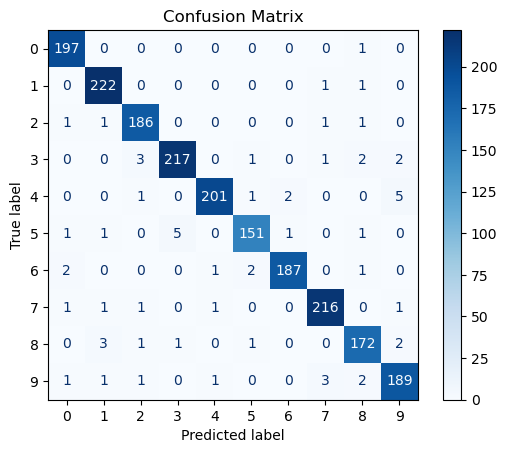

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [27]:
# I found the most confusing numbers by looping over the entries of the confusion matrix (which is just an numpy nd array, 2 dimensions, with height and width equal to the number of true classes). There might be a smarter way!

max_row = 0
max_col = 0
max_count = 0

###########################################################
# Write for loop logic here (or find your own better way!)
###########################################################
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i !=j:
            if cm[i,j]>max_count:
                max_row = i
                max_col = j
                max_count = cm[i, j]

print(f'The most confused numbers are {max_row} and {max_col}. It happened {max_count} times!')

The most confused numbers are 4 and 9. It happened 5 times!


In [28]:
correct = np.trace(cm)
print(correct)
incorrect = np.sum(cm)-np.trace(cm)
print(incorrect)

1938
62


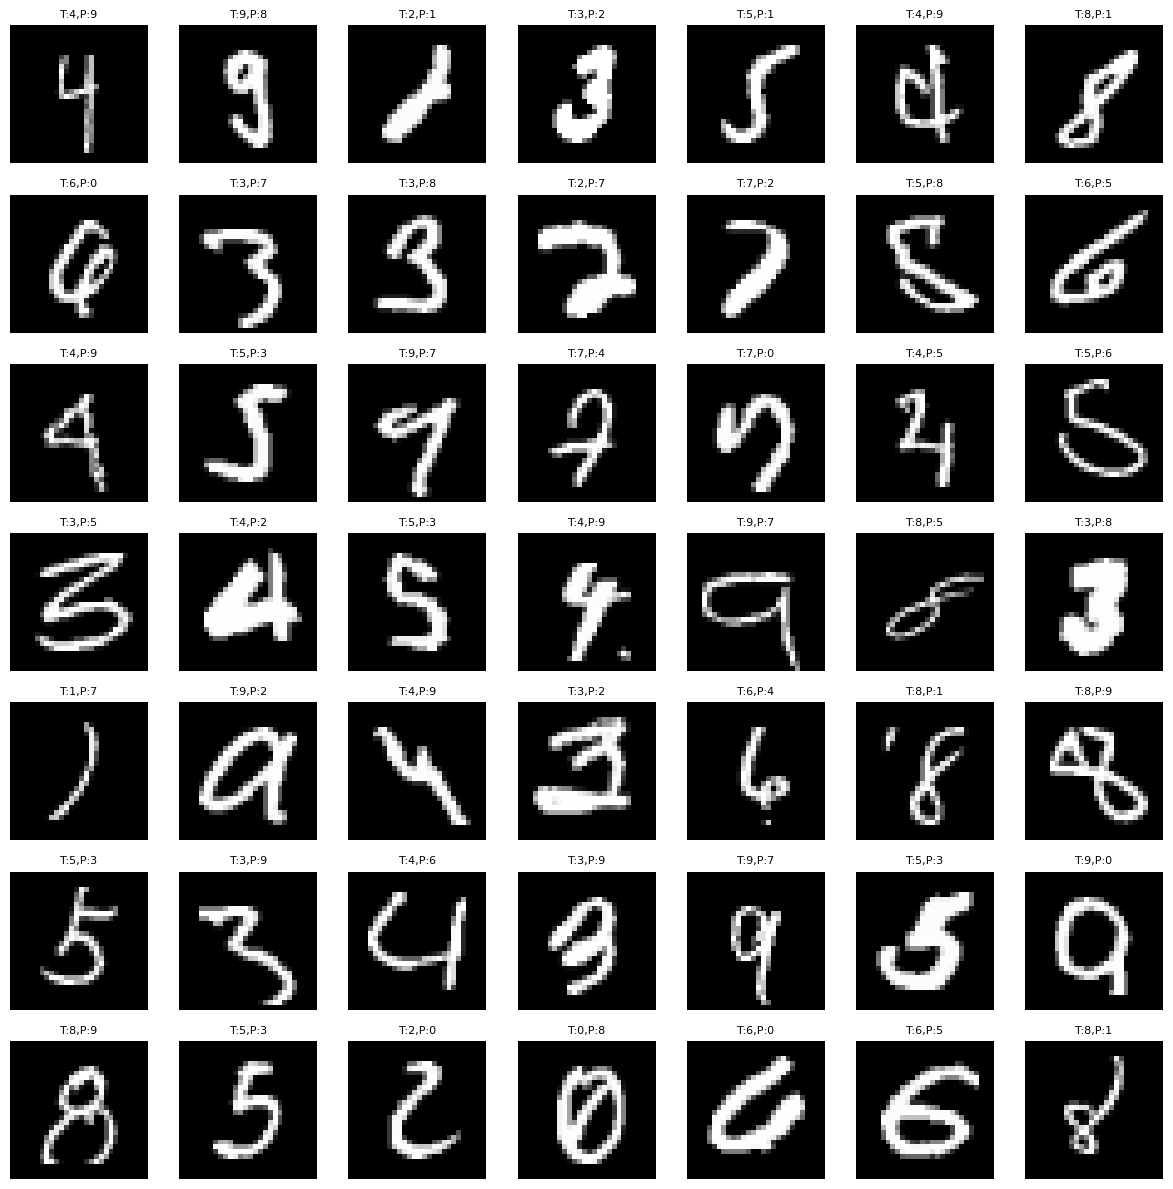

In [29]:
wrong = np.where(y_pred != y_test)[0]

num_images = 49
wrong_images = X_Test[wrong[:num_images]]
wrong_true_labels = np.array(y_test)[wrong[:num_images]]
wrong_pred_labels = y_pred[wrong[:num_images]]

plt.figure(figsize=( 12,12))

for i in range(num_images):
    plt.subplot(7,7,i+1)
    image = wrong_images[i].reshape(28,28)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(f'T:{wrong_true_labels[i]},P:{wrong_pred_labels[i]}', fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Hint: matplotlib.pyplot.imshow might be handy to display each instance.

<div style="background-color:#C2F5DD">

## Exercise 3
1. Define a new MLP model which is the same as the first but with a single hidden layer.
2. How does the time taken for each epoch and the time taken for training to converge overall differ from what we saw in Exercise 2?
4. Compare the performance of this new model to the first using the overall accuracies and confusion matrices of the two. Comment on what you observe.
5. Neural networks can be prone to overfitting. Which of the two networks would you expect to suffer more from overfitting? In these exercises have we seen evidence of overfitting? What proceedures would you perform to better assess whether there is overfitting and how would you change the network architecture based on what you found?

In [33]:
model1 = MLPClassifier(hidden_layer_sizes=(512,), max_iter=100, solver="adam", tol=0.0001, random_state=1, verbose=True)

In [34]:
model1.fit(X_train,y_train)

Iteration 1, loss = 0.78393181
Iteration 2, loss = 0.30934937
Iteration 3, loss = 0.23947859
Iteration 4, loss = 0.19199446
Iteration 5, loss = 0.15754850
Iteration 6, loss = 0.13125467
Iteration 7, loss = 0.10760716
Iteration 8, loss = 0.09068678
Iteration 9, loss = 0.07311802
Iteration 10, loss = 0.06048993
Iteration 11, loss = 0.05081863
Iteration 12, loss = 0.04400610
Iteration 13, loss = 0.03472095
Iteration 14, loss = 0.03168694
Iteration 15, loss = 0.02548493
Iteration 16, loss = 0.02163581
Iteration 17, loss = 0.01776742
Iteration 18, loss = 0.01598800
Iteration 19, loss = 0.01351629
Iteration 20, loss = 0.01150587
Iteration 21, loss = 0.01044156
Iteration 22, loss = 0.00957398
Iteration 23, loss = 0.00805532
Iteration 24, loss = 0.00734221
Iteration 25, loss = 0.00644869
Iteration 26, loss = 0.00579594
Iteration 27, loss = 0.00540079
Iteration 28, loss = 0.00494814
Iteration 29, loss = 0.00448154
Iteration 30, loss = 0.00416074
Iteration 31, loss = 0.00382223
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(512,), max_iter=100, random_state=1,
              verbose=True)

In [35]:
from sklearn.metrics import accuracy_score
y1_pred= model1.predict(X_Test)
accuracy = accuracy_score(y_test, y1_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9645


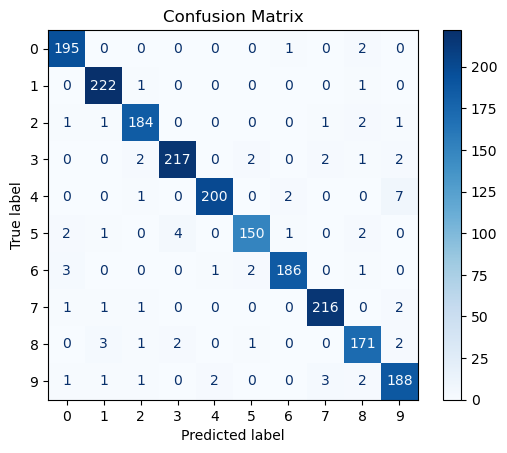

In [36]:

cm1 = confusion_matrix(y_test, y1_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [1]:


print("The accuracy of the test set is {:.5f}".format(test_accuracy_1_hidden_layer))
print("The accuracy of the train set is {:.5f}".format(train_accuracy_1_hidden_layer))

NameError: name 'test_accuracy_1_hidden_layer' is not defined

In [37]:
train_pred1 = model.predict(X_train)
test_pred1= model.predict(X_Test)

train_acc1 = accuracy_score(y_train,train_pred1)
test_acc1 = accuracy_score(y_test, test_pred1)

print("Model 1(Two hidden layers of 512 nodes each):")
print(f"Training Accuracy: {train_acc1:.4f}")
print(f"Testing Accuracy: {test_acc1:.4f}")
print()

train_pred2 = model1.predict(X_train)
test_pred2 = model1.predict(X_Test)

train_acc2 = accuracy_score(y_train, train_pred2)
test_acc2 = accuracy_score(y_test, test_pred2)

print("Model 2(1 hidden layer of 512 nodes):")
print(f"Training Accuracy: {train_acc2:.4f}")
print(f"Testing Accuracy: {test_acc2:.4f}")


Model 1(Two hidden layers of 512 nodes each):
Training Accuracy: 1.0000
Testing Accuracy: 0.9690

Model 2(1 hidden layer of 512 nodes):
Training Accuracy: 1.0000
Testing Accuracy: 0.9645
